In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

os.makedirs('../charts', exist_ok=True)

matches = pd.read_csv('../data/IPL Matches.csv')
deliveries = pd.read_csv('../data/IPL Ball-by-Ball.csv')

print(f"Matches: {matches.shape}")
print(f"Deliveries: {deliveries.shape}")
print(f"\nMatches columns:\n{matches.columns.tolist()}")
print(f"\nDeliveries columns:\n{deliveries.columns.tolist()}")

Matches: (816, 17)
Deliveries: (193468, 18)

Matches columns:
['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2']

Deliveries columns:
['id', 'inning', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'non_boundary', 'is_wicket', 'dismissal_kind', 'player_dismissed', 'fielder', 'extras_type', 'batting_team', 'bowling_team']


In [2]:
# Extract season from date
matches['date'] = pd.to_datetime(matches['date'])
matches['season'] = matches['date'].dt.year

# Check for nulls in key columns
print("Null values in matches:")
print(matches[['winner', 'toss_winner', 'toss_decision', 'season']].isnull().sum())

print(f"\nSeasons: {sorted(matches['season'].unique())}")
print(f"Total teams: {matches['team1'].nunique()}")
print(f"Unique venues: {matches['venue'].nunique()}")

# Preview
matches[['id','season','team1','team2','toss_winner','toss_decision','winner']].head()

Null values in matches:
winner           4
toss_winner      0
toss_decision    0
season           0
dtype: int64

Seasons: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Total teams: 15
Unique venues: 36


,id,season,team1,team2,toss_winner,toss_decision,winner
0,335982,2008,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders
1,335983,2008,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,335984,2008,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils
3,335985,2008,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore
4,335986,2008,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders


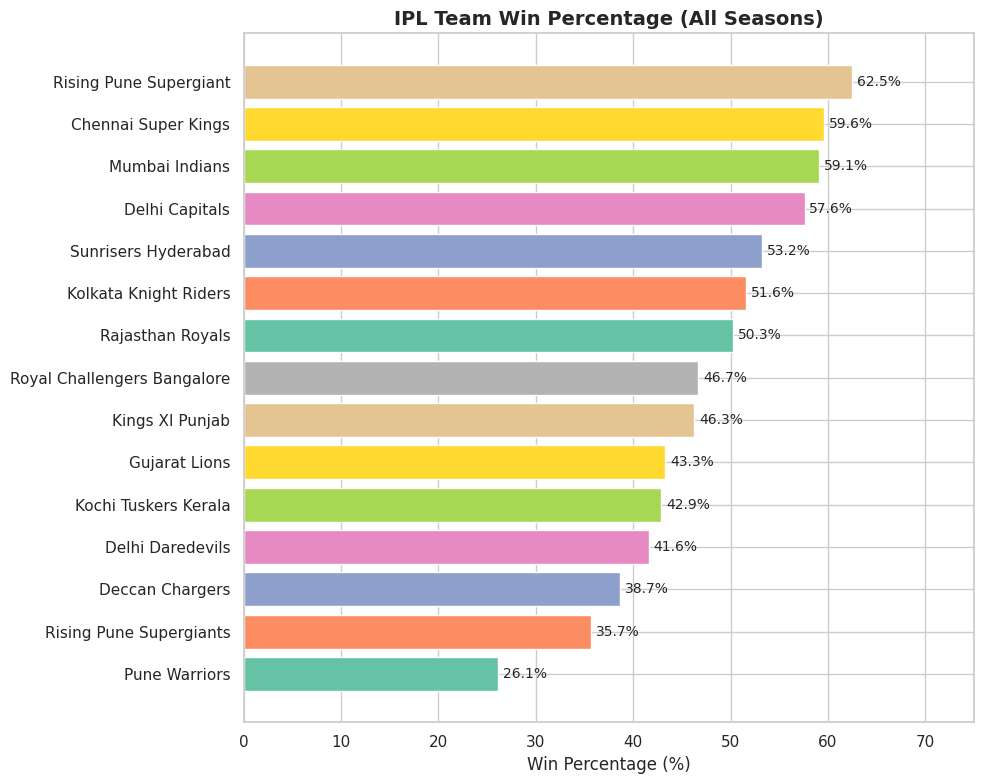

Chart saved.


In [3]:
total_matches = pd.concat([
    matches['team1'], matches['team2']
]).value_counts().reset_index()
total_matches.columns = ['team', 'played']

wins = matches['winner'].value_counts().reset_index()
wins.columns = ['team', 'wins']

team_stats = total_matches.merge(wins, on='team')
team_stats['win_pct'] = (team_stats['wins'] / team_stats['played'] * 100).round(1)
team_stats = team_stats.sort_values('win_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette("Set2", len(team_stats))
bars = ax.barh(team_stats['team'], team_stats['win_pct'], color=colors)
ax.set_xlabel('Win Percentage (%)')
ax.set_title('IPL Team Win Percentage (All Seasons)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 75)
for bar, val in zip(bars, team_stats['win_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../charts/01_team_win_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

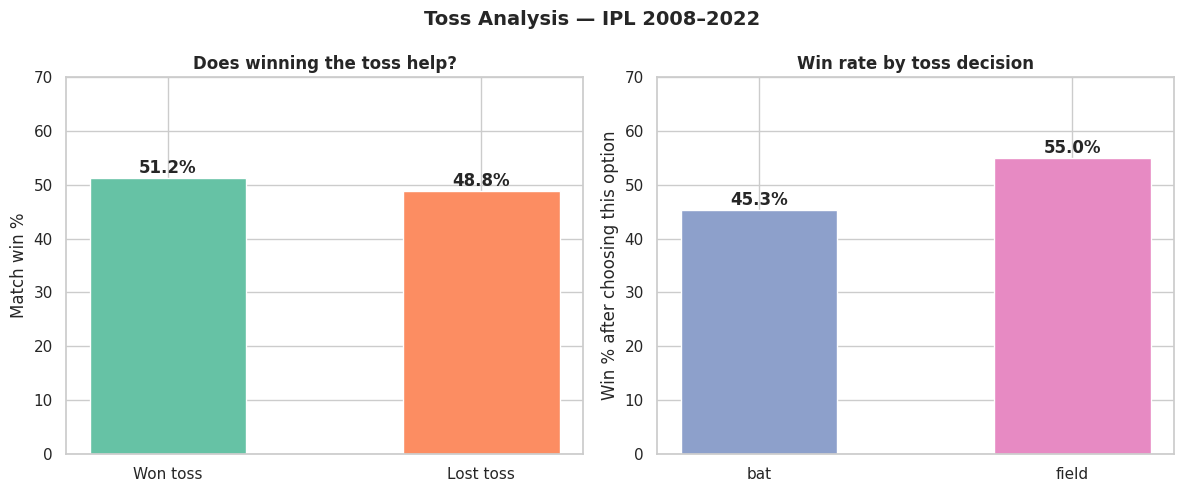

Chart saved.


In [4]:
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']

overall = matches['toss_won_match'].mean() * 100

toss_by_decision = matches.groupby('toss_decision')['toss_won_match'].mean().reset_index()
toss_by_decision.columns = ['decision', 'win_rate']
toss_by_decision['win_rate'] = (toss_by_decision['win_rate'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overall toss effect
axes[0].bar(['Won toss', 'Lost toss'],
            [overall, 100 - overall],
            color=['#66c2a5', '#fc8d62'], width=0.5)
axes[0].set_title('Does winning the toss help?', fontweight='bold')
axes[0].set_ylabel('Match win %')
axes[0].set_ylim(0, 70)
for i, v in enumerate([overall, 100 - overall]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Right: field vs bat
axes[1].bar(toss_by_decision['decision'], toss_by_decision['win_rate'],
            color=['#8da0cb', '#e78ac3'], width=0.5)
axes[1].set_title('Win rate by toss decision', fontweight='bold')
axes[1].set_ylabel('Win % after choosing this option')
axes[1].set_ylim(0, 70)
for i, row in toss_by_decision.iterrows():
    axes[1].text(i, row['win_rate'] + 1, f"{row['win_rate']}%",
                 ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Toss Analysis — IPL 2008–2022', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/02_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

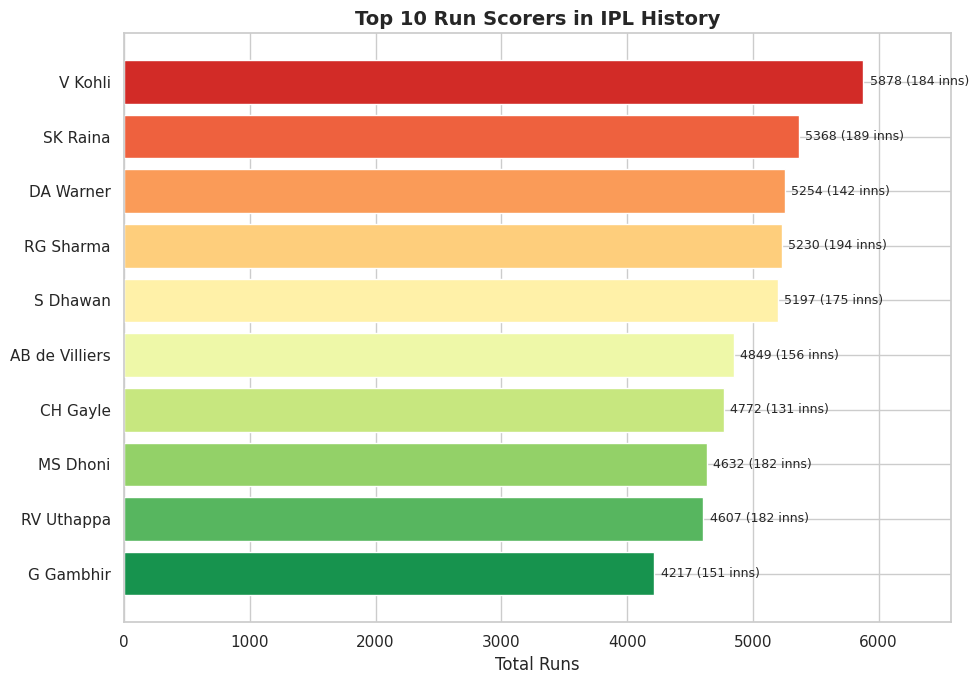

Chart saved.


In [5]:
batsman_runs = deliveries.groupby('batsman')['batsman_runs'].sum().reset_index()
batsman_runs.columns = ['batsman', 'total_runs']

# Also get innings count for context
innings = deliveries.groupby('batsman')['id'].nunique().reset_index()
innings.columns = ['batsman', 'innings']

batsman_runs = batsman_runs.merge(innings, on='batsman')
batsman_runs['avg'] = (batsman_runs['total_runs'] / batsman_runs['innings']).round(1)

top10 = batsman_runs.sort_values('total_runs', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("RdYlGn", 10)[::-1]
bars = ax.barh(top10['batsman'][::-1], top10['total_runs'][::-1], color=colors)
ax.set_xlabel('Total Runs')
ax.set_title('Top 10 Run Scorers in IPL History', fontsize=14, fontweight='bold')
ax.set_xlim(0, top10['total_runs'].max() + 700)
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(row['total_runs'] + 50,
            bar.get_y() + bar.get_height()/2,
            f"{int(row['total_runs'])} ({row['innings']} inns)",
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/03_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

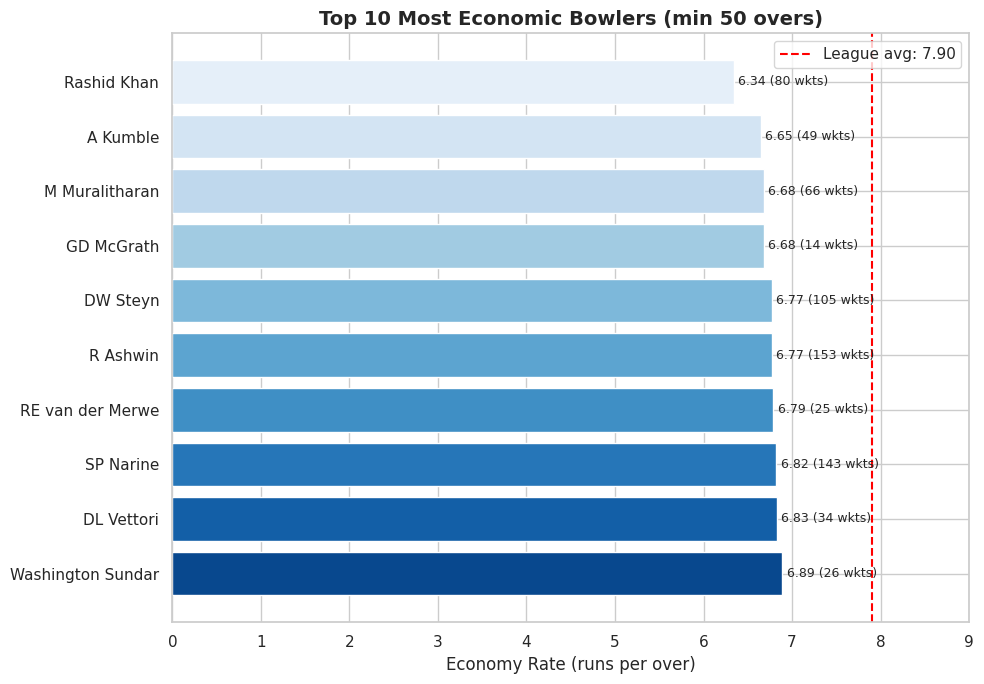

Chart saved.


In [6]:
bowler_stats = deliveries.groupby('bowler').agg(
    runs_given=('total_runs', 'sum'),
    balls=('ball', 'count'),
    wickets=('is_wicket', 'sum')        # this dataset uses is_wicket (0/1)
).reset_index()

bowler_stats['overs'] = (bowler_stats['balls'] / 6).round(1)
bowler_stats['economy'] = (bowler_stats['runs_given'] / bowler_stats['overs']).round(2)
bowler_stats['bowling_sr'] = (bowler_stats['balls'] / bowler_stats['wickets']).round(1)

# Minimum 50 overs bowled
qualified = bowler_stats[bowler_stats['overs'] >= 50].copy()
top_economy = qualified.sort_values('economy').head(10)
avg_economy = qualified['economy'].mean()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_economy['bowler'][::-1],
               top_economy['economy'][::-1],
               color=sns.color_palette("Blues_r", 10))
ax.set_xlabel('Economy Rate (runs per over)')
ax.set_title('Top 10 Most Economic Bowlers (min 50 overs)', fontsize=14, fontweight='bold')
ax.axvline(x=avg_economy, color='red', linestyle='--', linewidth=1.5,
           label=f'League avg: {avg_economy:.2f}')
ax.legend()
ax.set_xlim(0, 9)
for bar, (_, row) in zip(bars, top_economy[::-1].iterrows()):
    ax.text(row['economy'] + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"{row['economy']} ({int(row['wickets'])} wkts)",
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/04_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

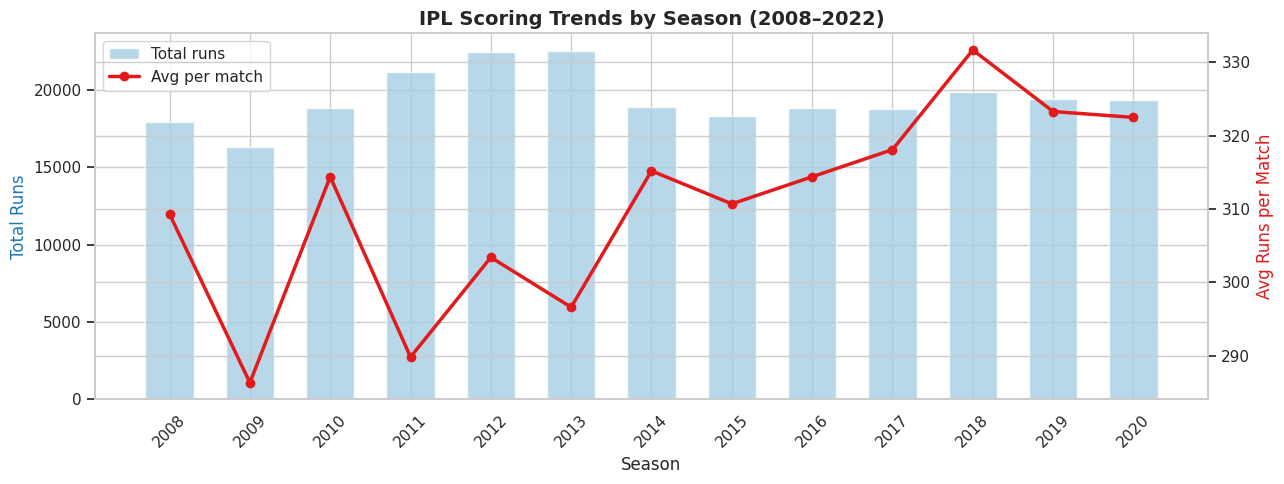

Chart saved.


In [7]:
# Merge season into deliveries
season_map = matches[['id', 'season']].copy()
deliveries_s = deliveries.merge(season_map, on='id')

season_totals = deliveries_s.groupby('season')['total_runs'].sum().reset_index()
matches_per_season = matches.groupby('season').size().reset_index(name='match_count')
season_totals = season_totals.merge(matches_per_season, on='season')
season_totals['avg_per_match'] = (season_totals['total_runs'] / season_totals['match_count']).round(1)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(season_totals['season'], season_totals['total_runs'],
        color='#a6cee3', alpha=0.8, label='Total runs', width=0.6)
ax2.plot(season_totals['season'], season_totals['avg_per_match'],
         color='#e31a1c', marker='o', linewidth=2.5, label='Avg per match')

ax1.set_xlabel('Season')
ax1.set_ylabel('Total Runs', color='#1f78b4')
ax2.set_ylabel('Avg Runs per Match', color='#e31a1c')
ax1.set_title('IPL Scoring Trends by Season (2008–2022)', fontsize=14, fontweight='bold')
ax1.set_xticks(season_totals['season'])
ax1.set_xticklabels(season_totals['season'], rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../charts/05_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

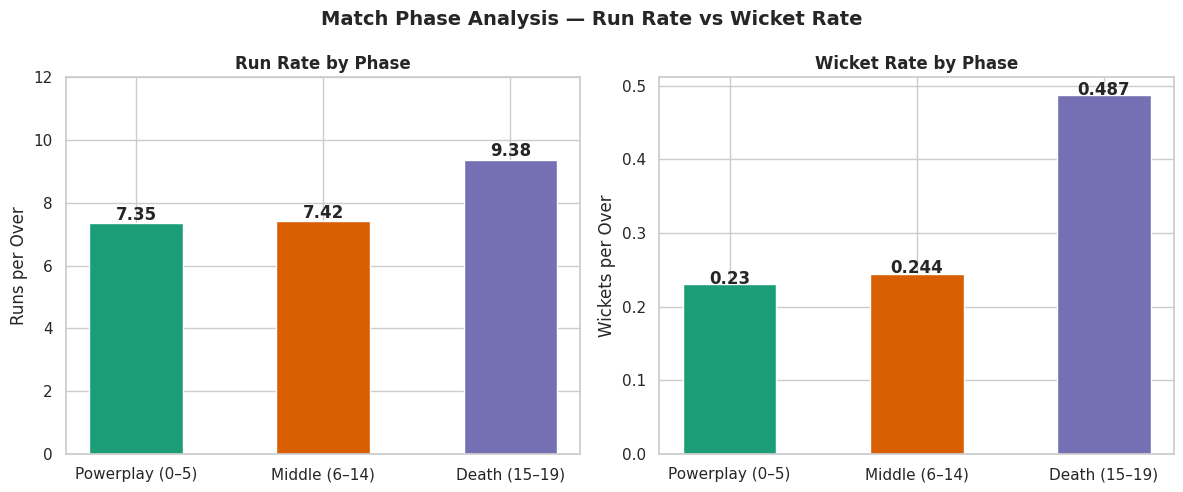

Chart saved.


In [8]:
def over_phase(over):
    if over <= 5:
        return 'Powerplay (0–5)'
    elif over <= 14:
        return 'Middle (6–14)'
    else:
        return 'Death (15–19)'

deliveries_s['phase'] = deliveries_s['over'].apply(over_phase)

phase_stats = deliveries_s.groupby('phase').agg(
    total_runs=('total_runs', 'sum'),
    balls=('ball', 'count'),
    wickets=('is_wicket', 'sum')
).reset_index()
phase_stats['run_rate'] = (phase_stats['total_runs'] / phase_stats['balls'] * 6).round(2)
phase_stats['wicket_rate'] = (phase_stats['wickets'] / phase_stats['balls'] * 6).round(3)

order = ['Powerplay (0–5)', 'Middle (6–14)', 'Death (15–19)']
phase_stats = phase_stats.set_index('phase').loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#1b9e77', '#d95f02', '#7570b3']

axes[0].bar(phase_stats['phase'], phase_stats['run_rate'], color=colors, width=0.5)
axes[0].set_title('Run Rate by Phase', fontweight='bold')
axes[0].set_ylabel('Runs per Over')
axes[0].set_ylim(0, 12)
for i, v in enumerate(phase_stats['run_rate']):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

axes[1].bar(phase_stats['phase'], phase_stats['wicket_rate'], color=colors, width=0.5)
axes[1].set_title('Wicket Rate by Phase', fontweight='bold')
axes[1].set_ylabel('Wickets per Over')
for i, v in enumerate(phase_stats['wicket_rate']):
    axes[1].text(i, v + 0.001, str(v), ha='center', fontweight='bold')

plt.suptitle('Match Phase Analysis — Run Rate vs Wicket Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/06_phase_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Key Findings

**1. CSK and MI are the true powerhouses** — despite Rising Pune Supergiant's 62.5% 
win rate, they played only 2 seasons. CSK (59.6%) and MI (59.1%) are the most 
consistent teams across 13 seasons.

**2. Toss advantage is a myth** — toss winners win only 51.2% of matches, barely 
better than a coin flip. However, teams choosing to **field first win 55%** vs 
only 45.3% when batting first — fielding is the smarter toss decision.

**3. Rashid Khan is the most economical bowler** at 6.34 runs/over with 80 wickets. 
9 of the top 10 most economic bowlers are spinners — confirming spinners 
control middle overs in T20 cricket.

**4. Death overs are the most explosive and dangerous phase** — run rate peaks at 
9.38 RPO (overs 15–19), 27% higher than powerplay (7.35). Wicket rate also 
doubles in death overs (0.487 vs 0.23), making death bowling the most 
critical and scarce skill in IPL auctions.

**5. 2009 was an outlier season** — hosted in South Africa due to elections, 
average runs per match dipped to ~288, the lowest in IPL history. 
Post-2014, scoring consistently stayed above 315 RPM.

**6. IPL scoring has evolved significantly** — average runs per match grew from 
~310 in 2008 to ~330+ in 2018, reflecting advances in batting techniques, 
smaller ground dimensions, and increased bat size regulations.

## Dataset
- 816 matches · 193,468 deliveries · 13 seasons (2008–2020)  
- Source: Kaggle — IPL Complete Dataset

## Tools
Python · pandas · matplotlib · seaborn